# Climate-Driven Disease Surveillance

This notebook runs the `disease` module for an approximate Kisumu County AOI.
The model estimates climate suitability for disease outbreaks from rainfall,
temperature, standing water, elevation, population density, vegetation, and
land-cover conditions.

The output is a climate-risk proxy; it is not a diagnosis or a replacement for
epidemiological surveillance and reported case data.


## Before you run

Use recent months for current conditions or a longer period for trend context.
Earth Engine credentials and `GEE_PROJECT` must be configured before execution.


In [1]:
from dataclasses import asdict
from pathlib import Path
import os

from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
from dotenv import load_dotenv

from climate_change import USE_CASE_REGISTRY, run_analysis

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
load_dotenv(PROJECT_ROOT / ".env")

GEE_PROJECT = os.environ.get("GEE_PROJECT", "").strip()
if not GEE_PROJECT:
    raise RuntimeError(
        "Set GEE_PROJECT in your shell or in the repository .env file before running this notebook."
    )

OUTPUT_DIR = PROJECT_ROOT / "outputs"
REPORT_DIR = PROJECT_ROOT / "reports"
OUTPUT_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)

In [2]:
module_info = USE_CASE_REGISTRY["disease"]
print(module_info.name)
print(module_info.date_guidance)
print("Models:", [option.id for option in module_info.model_options])

Climate-Driven Disease Surveillance
Select the most recent 3-6 months for current risk; up to 2 years for trend analysis.
Models: ['gbm', 'xgboost', 'ensemble']


In [3]:
# Approximate Kisumu County and the northeastern Lake Victoria shore.
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [34.10, -0.80],
            [35.00, -0.80],
            [35.00, 0.20],
            [34.10, 0.20],
            [34.10, -0.80],
        ]
    ],
}

analysis_args = {
    "module": "disease",
    "aoi_geojson": aoi,
    "start_date": "2021-01-01",
    "end_date": "2023-12-31",
    "country": "Kenya",
    "gee_project": GEE_PROJECT,
    "extra_params": {
        "model_type": "gbm",  # "gbm", "xgboost", or "ensemble"
        "n_pixels": 3000,
        "scale": 1000,
        "output_dir": str(OUTPUT_DIR),
        "prefix": "kisumu_disease_risk",
    },
}

In [4]:
output = await run_analysis(**analysis_args)

2026-06-24 13:59:24,844 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
/home/odero-george/workspace/climate-change/.venv/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36105 instead
  warnings.warn(
2026-06-24 13:59:24,863 - distributed.scheduler - INFO - State start
2026-06-24 13:59:24,866 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:37065
2026-06-24 13:59:24,867 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:36105/status
2026-06-24 13:59:24,867 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-06-24 13:59:24,878 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:46041'
2026-06-24 13:59:24,880 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:40427'
2

In [5]:
print("Module:", output.module)
print("Raster output:", output.raster_path)
print("GeoJSON features:", len(output.geojson.get("features", [])))
print("Chart keys:", sorted(output.charts))
print("Metadata:", output.metadata)
output.stats

Module: disease
Raster output: {'disease_risk': '/home/odero-george/workspace/climate-change/outputs/kisumu_disease_risk_disease_risk.tif'}
GeoJSON features: 2556
Chart keys: ['hotspots', 'model_performance', 'riskDist', 'shap', 'timeSeries']
Metadata: {'model': 'gbm', 'country': 'Kenya', 'start_date': '2021-01-01', 'end_date': '2023-12-31', 'raster': {'disease_risk': '/home/odero-george/workspace/climate-change/outputs/kisumu_disease_risk_disease_risk.tif'}}


{'model_type': 'gbm',
 'n_pixels_sampled': 2555,
 'gbm_cv_f1': 0.9672,
 'gbm_f1': 0.9588,
 'gbm_accuracy': 0.9589,
 'xgb_cv_f1': 0.9691,
 'xgb_f1': 0.9648,
 'xgb_accuracy': 0.9648,
 'ensemble_f1': 0.9549,
 'selected_f1': 0.9588,
 'high_risk_pct': 33.4,
 'n_hotspot_clusters': 1,
 'top_driver': 'temp_mean',
 'country': 'Kenya'}

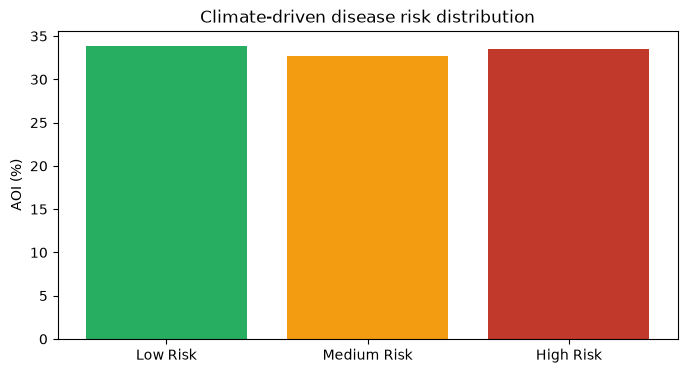

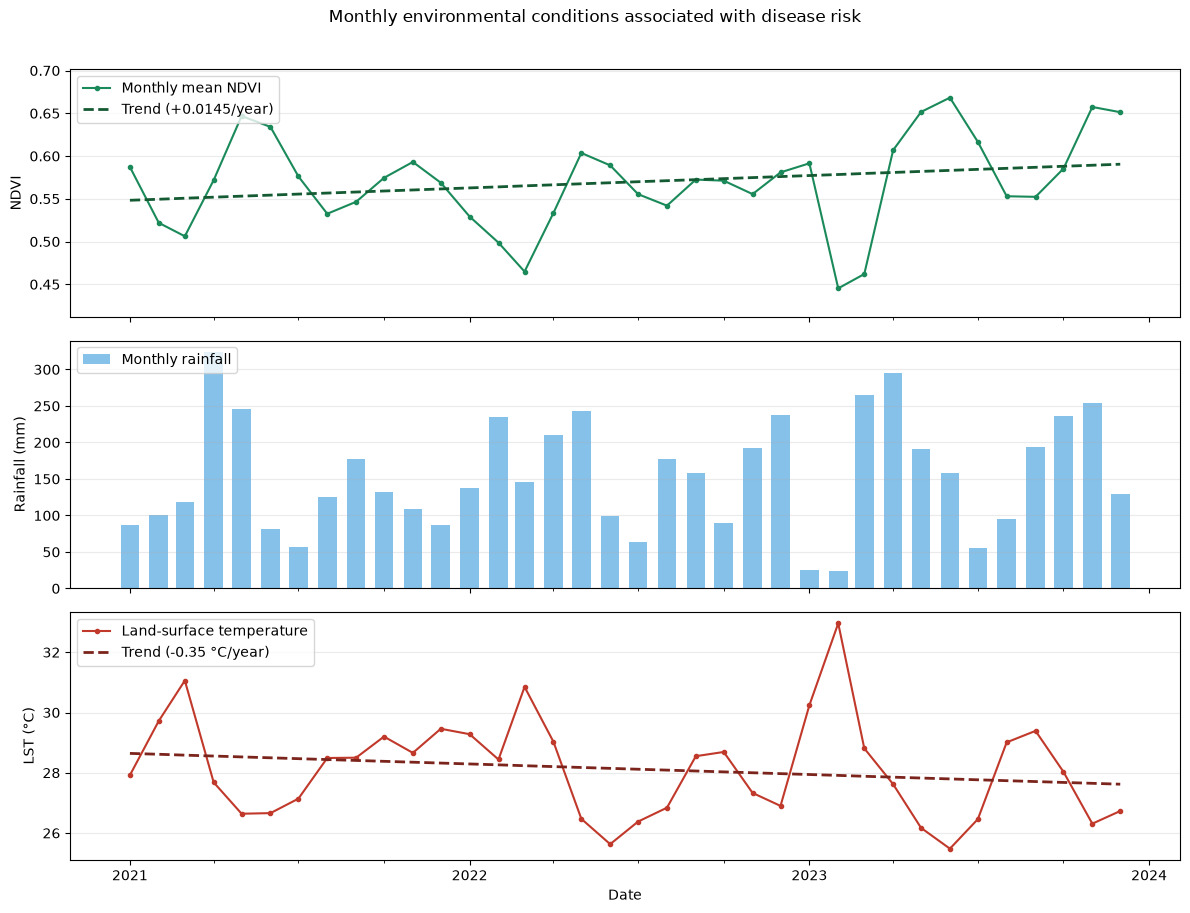

In [6]:
risk = output.charts.get("riskDist", {})
if risk.get("labels"):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(risk["labels"], risk["data"], color=["#27AE60", "#F39C12", "#C0392B"])
    ax.set_ylabel("AOI (%)")
    ax.set_title("Climate-driven disease risk distribution")
    plt.show()

series = output.charts.get("timeSeries", {})
if series.get("labels"):
    import matplotlib.dates as mdates
    import numpy as np
    import pandas as pd

    dates = pd.to_datetime(series["labels"], format="%Y-%m")
    datasets = {item["label"]: item["data"] for item in series.get("datasets", [])}
    ndvi = np.asarray(datasets.get("NDVI", []), dtype=float)
    rainfall = np.asarray(datasets.get("Monthly rain (mm)", []), dtype=float)
    temperature = np.asarray(datasets.get("LST (°C)", []), dtype=float)

    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    ndvi_ax, rain_ax, temp_ax = axes
    month_number = np.arange(len(dates), dtype=float)

    if ndvi.size:
        ndvi_ax.plot(
            dates,
            ndvi,
            color="#1B8A5A",
            marker="o",
            markersize=3,
            linewidth=1.5,
            label="Monthly mean NDVI",
        )
        valid = np.isfinite(ndvi)
        if valid.sum() >= 2:
            slope, intercept = np.polyfit(month_number[valid], ndvi[valid], 1)
            ndvi_ax.plot(
                dates,
                intercept + slope * month_number,
                color="#145A32",
                linestyle="--",
                linewidth=2,
                label=f"Trend ({slope * 12:+.4f}/year)",
            )
        finite_ndvi = ndvi[np.isfinite(ndvi)]
        if finite_ndvi.size:
            padding = max(0.03, float(np.ptp(finite_ndvi)) * 0.15)
            ndvi_ax.set_ylim(
                max(-1.0, float(finite_ndvi.min()) - padding),
                min(1.0, float(finite_ndvi.max()) + padding),
            )
    ndvi_ax.set_ylabel("NDVI")
    ndvi_ax.legend(loc="upper left")
    ndvi_ax.grid(axis="y", alpha=0.25)

    if rainfall.size:
        rain_ax.bar(
            dates,
            rainfall,
            width=20,
            color="#5DADE2",
            alpha=0.75,
            label="Monthly rainfall",
        )
    rain_ax.set_ylabel("Rainfall (mm)")
    rain_ax.legend(loc="upper left")
    rain_ax.grid(axis="y", alpha=0.25)

    if temperature.size:
        temp_ax.plot(
            dates,
            temperature,
            color="#C0392B",
            marker="o",
            markersize=3,
            linewidth=1.5,
            label="Land-surface temperature",
        )
        valid = np.isfinite(temperature)
        if valid.sum() >= 2:
            slope, intercept = np.polyfit(month_number[valid], temperature[valid], 1)
            temp_ax.plot(
                dates,
                intercept + slope * month_number,
                color="#7B241C",
                linestyle="--",
                linewidth=2,
                label=f"Trend ({slope * 12:+.2f} °C/year)",
            )
    temp_ax.set_ylabel("LST (°C)")
    temp_ax.set_xlabel("Date")
    temp_ax.legend(loc="upper left")
    temp_ax.grid(axis="y", alpha=0.25)
    temp_ax.xaxis.set_major_locator(mdates.YearLocator())
    temp_ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    temp_ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))

    fig.suptitle("Monthly environmental conditions associated with disease risk", y=1.01)
    fig.tight_layout()
    plt.show()

In [7]:
# Optional: generate a PDF report in a second call.
# Set this to True only when you want the extra analysis/report run.
GENERATE_REPORT = False

if GENERATE_REPORT:
    report_output = await run_analysis(
        **analysis_args,
        report_output_dir=str(REPORT_DIR),
    )
    print("Report:", report_output.metadata.get("report_path"))

Report: /home/odero-george/workspace/climate-change/reports/disease_20260624_105943.pdf
